In [1]:
import torch
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from model import get_model
from forward_operator import get_operator
from sampler import get_sampler


/home/jovyan/project/Deep_Learning_DAPS/daps_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load model config (ddpm)
model_cfg_path = 'configs/model/ffhq256ddpm.yaml'
model_cfg = OmegaConf.load(model_cfg_path)
model = get_model(**model_cfg).cuda()
model.eval()

# Load task/operator config
task_cfg_path = 'configs/task/scribble_inpainting.yaml'
task_cfg = OmegaConf.load(task_cfg_path)

# Use pixel-space box inpainting
pixel_cfg = task_cfg.pixel
operator_cfg = pixel_cfg.operator
mcmc_cfg = pixel_cfg.mcmc_sampler_config

print("Operator config:", operator_cfg)
print("MCMC config:", mcmc_cfg)



Operator config: {'name': 'scribble_inpainting', 'mask_path': 'Irregular_mask/00001.jpg', 'resolution': 256, 'sigma': 0.05}
MCMC config: {'num_steps': 100, 'lr': 5e-05, 'tau': 0.01, 'lr_min_ratio': 0.01, 'mc_algo': 'langevin', 'prior_solver': 'gaussian'}


In [3]:
#Load a dataset using a config file
from data import get_dataset
dataset_config_yaml = 'configs/data/ffhq.yaml'
dataset_config = OmegaConf.load(dataset_config_yaml)
dataset = get_dataset(**dataset_config)
images = dataset.get_data(5)

In [4]:
from torchvision.utils import save_image
import PIL
def visualize_grid(images,title = "image", target='image.png', nrow=10, figsize=None, normalize=True):
    # Save images.
    save_grid(images, target, nrow=nrow, normalize=normalize)
    visualize_pil(target,title, figsize=figsize)


def save_grid(images, target='image.png', nrow=10, normalize=True):
    # Save images.
    if normalize:
        images = norm_image_01(images)
    save_image(images, target, nrow=nrow)

def norm_image_01(x):
    return (x * 0.5 + 0.5).clip(0, 1)

def visualize_pil(target,title, figsize=None):
    pil_image = PIL.Image.open(target)
    if figsize is None:
        plt.figure(figsize=(24, 24))
    else:
        plt.figure(figsize=figsize)
    plt.imshow(pil_image)
    plt.title(title)
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()


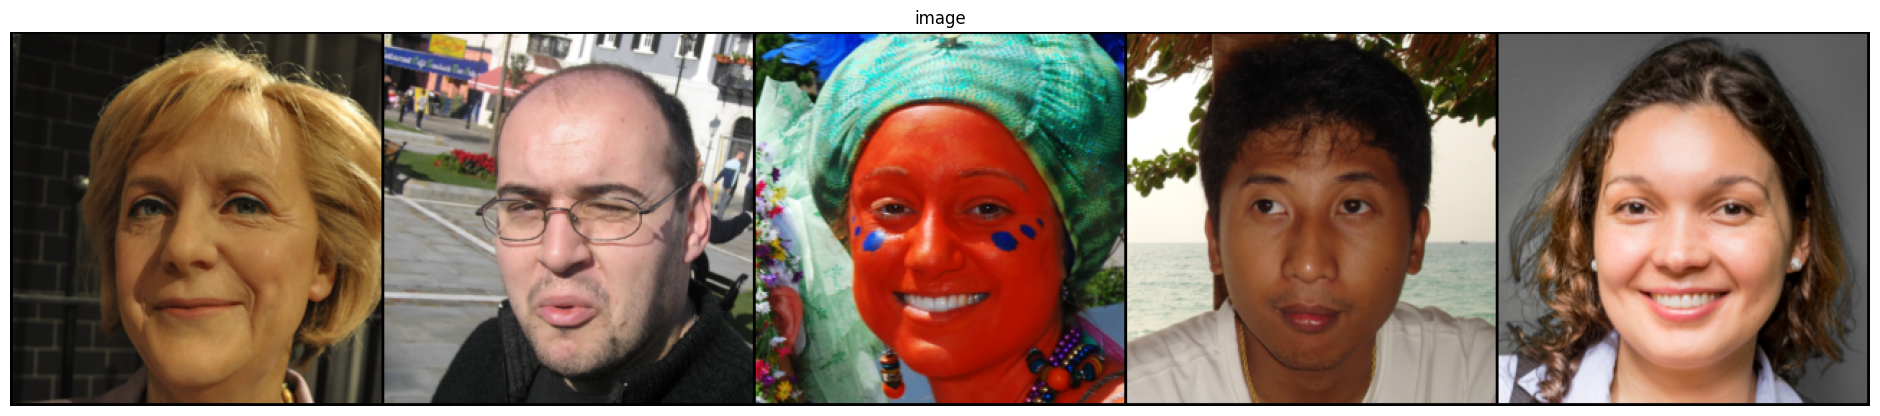

In [5]:
visualize_grid(images, nrow=10)

In [6]:
operator = get_operator(**operator_cfg)
y = operator.measure(images)
mask = operator.mask       # mask generated inside the operator

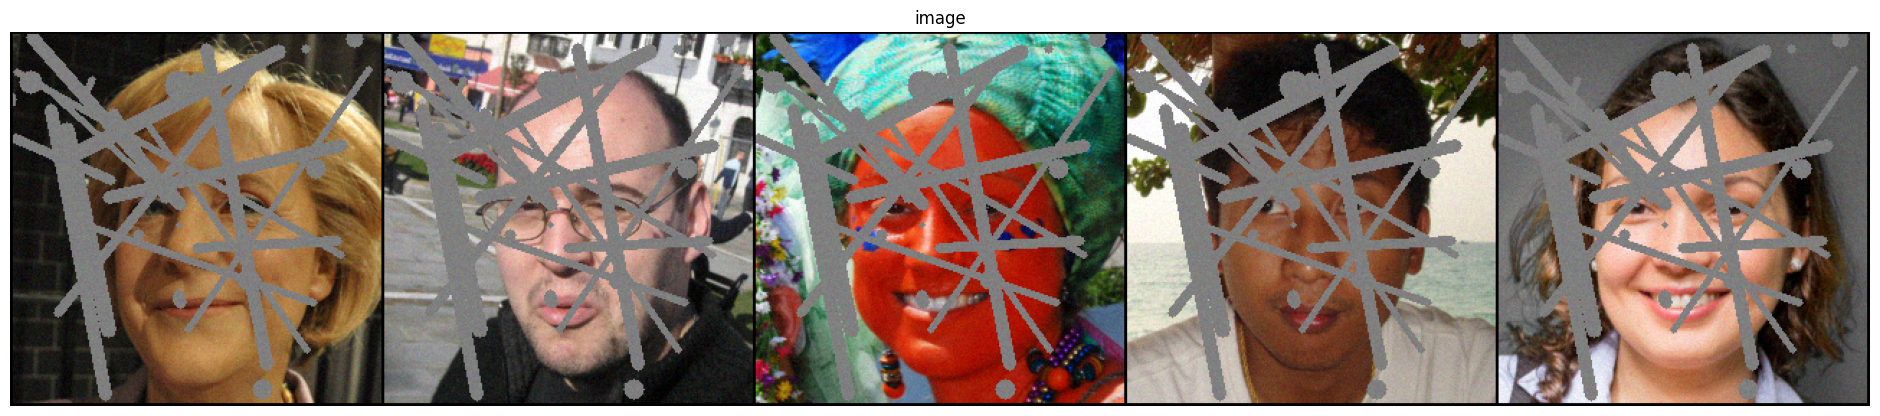

In [7]:
visualize_grid(y, nrow=10)

In [8]:
# Load sampler YAML
sampler_cfg_path = "configs/sampler/edm_daps.yaml"
sampler_cfg = OmegaConf.load(sampler_cfg_path)

In [9]:
# Construct sampler
sampler = get_sampler(
    latent=sampler_cfg.latent,
    annealing_scheduler_config=sampler_cfg.annealing_scheduler_config,
    diffusion_scheduler_config=sampler_cfg.diffusion_scheduler_config,
    mcmc_sampler_config=mcmc_cfg  # from pixel/inpainting config
)


In [10]:
# DAPS requires a starting point
x_start = sampler.get_start(batch_size=5, model=model)

In [11]:
# Run DAPS
# with torch.no_grad():
daps_result = sampler.sample(
        model=model,
        x_start=x_start,
        operator=operator,
        measurement=y,
        verbose=True
    )

100%|██████████| 200/200 [01:49<00:00,  1.83it/s]


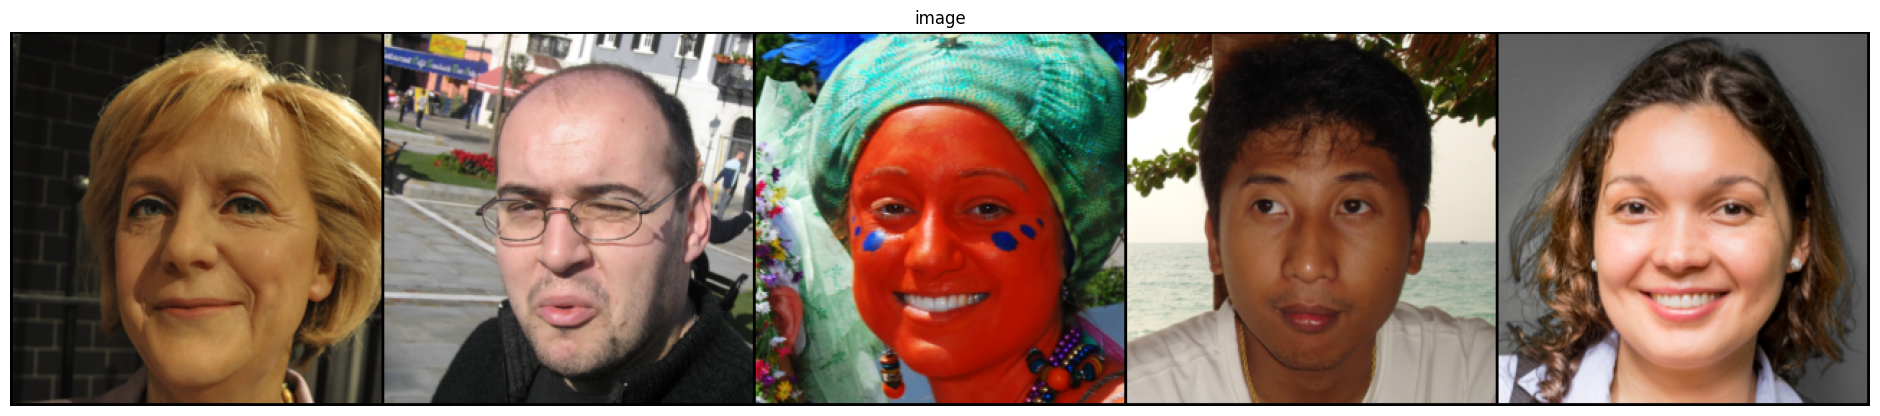

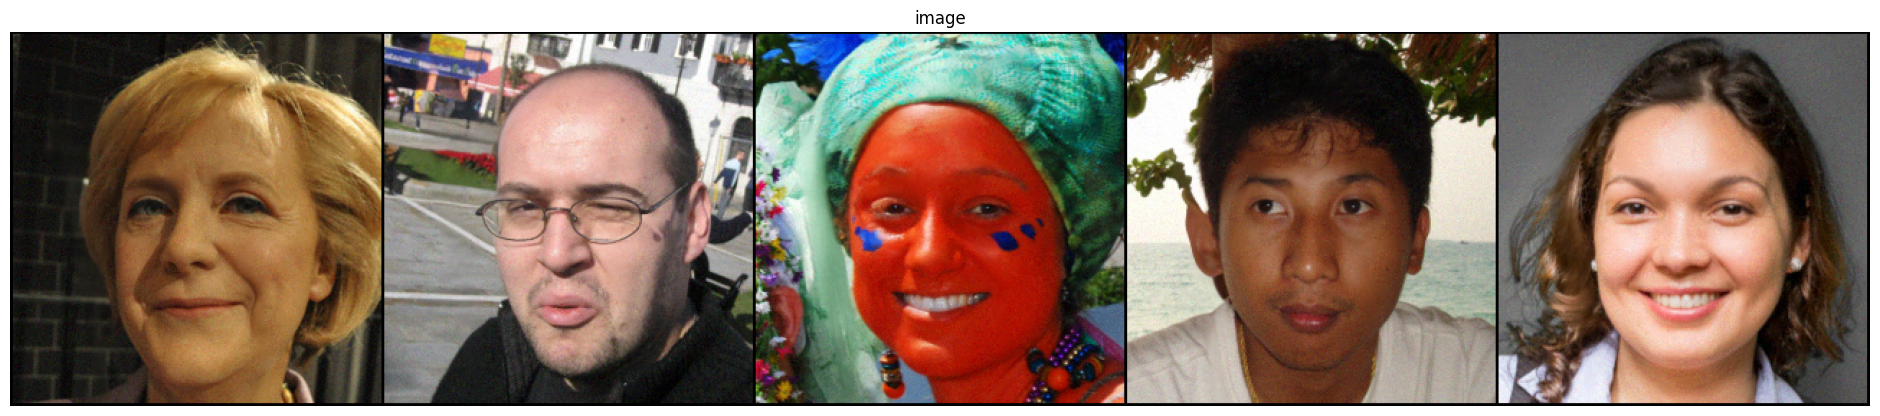

In [12]:
visualize_grid(images, nrow=10)
visualize_grid(daps_result, nrow=10)

## With Our sampler

In [13]:
from main.scheduler import EDMScheduler
num_steps = 5
edmsampler1 = EDMScheduler(num_steps)
img1 = images[0]
img1.shape
(5, *img1.shape)
tuple(images.shape)


(5, 3, 256, 256)

In [14]:

from main.pfode import PFODE
pf_ode = PFODE(edmsampler1, model, (5, *img1.shape))
x_T = pf_ode.gaussian_prior_x_T(5)
x_0 = pf_ode.solve(x_T)

In [15]:
# visualize_grid(x_T, nrow=5)
# visualize_grid(x_0, nrow=5)

In [16]:
from daps_sampler import MCMC_Langevin
x_0.requires_grad
mcmc_lv = MCMC_Langevin(eta = mcmc_cfg['lr'], beta_y = mcmc_cfg['tau'], iter = mcmc_cfg['num_steps'])
x0_cond, x0_cond_list = mcmc_lv.mcmc_chain(x0_hat= x_0, measurement= y, operator=operator, r_t = 100)


100%|██████████| 100/100 [00:00<00:00, 2431.14it/s]


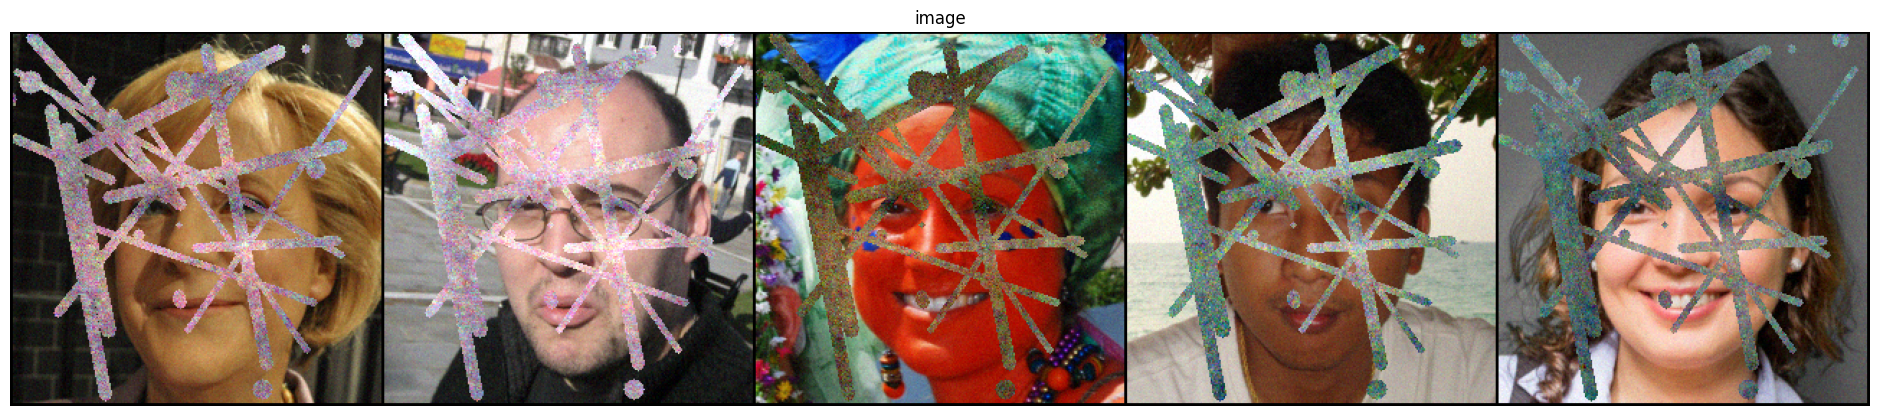

In [17]:
visualize_grid(x0_cond, nrow=5)

In [18]:

from daps_sampler import DAPS
daps = DAPS(sampler_cfg['annealing_scheduler_config'], sampler_cfg['diffusion_scheduler_config'], mcmc_cfg)
x_init = pf_ode.gaussian_prior_x_T(5)
x_final = daps.daps_sample(model, x_init, operator, y)

100%|██████████| 200/200 [00:29<00:00,  6.89it/s]


In [1]:
visualize_grid(images,title = "Original image", nrow=10)
visualize_grid(y,title = "Masked image", nrow=10)
visualize_grid(daps_result, title = "DAPS-Sampler image", nrow=10)
visualize_grid(x_final,title = "Our-Sampler image", nrow=10)

NameError: name 'visualize_grid' is not defined